# Hydrate Formation Risk along Flowlines

**Goal:** learn the hydrate risk boundary from operating data and verify it against
thermodynamics; produce the safe-operating-envelope chart with inhibitor sensitivity.

**Technique highlights**
* Physics-comparable feature design (log P) so the ML boundary can be validated
* Probability contours = risk envelope, not just a hard boundary
* MEG dosage sensitivity — an operational what-if straight from the model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Operating history with hydrate events

True physics: hydrate equilibrium T_eq = a·ln(P) + b, depressed by MEG. Events occur
when operating T falls below T_eq with some stochasticity (kinetics, water salinity).

In [2]:
N = 6_000
p_psia = rng.uniform(400, 4_000, N)
t_f = rng.uniform(35, 90, N)
meg_wt = np.where(rng.random(N) < 0.5, 0.0, rng.uniform(5, 40, N))

def t_eq(p, meg):
    return 8.9 * np.log(p) - 4.0 - 0.62 * meg   # °F, simplified Katz + Hammerschmidt

subcooling = t_eq(p_psia, meg_wt) - t_f          # positive = inside hydrate region
p_event = 1 / (1 + np.exp(-(subcooling - 1.5)))  # kinetics: not every excursion plugs
hydrate = (rng.random(N) < p_event).astype(int)

df = pd.DataFrame({"p_psia": p_psia.round(0), "t_f": t_f.round(1),
                   "meg_wt_pct": meg_wt.round(1), "hydrate_event": hydrate})
df.to_csv("flowline_operating_points.csv", index=False)
print(f"Event rate: {hydrate.mean():.1%}")

Event rate: 35.4%


## 2. Logistic regression with physics-shaped features

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

df["ln_p"] = np.log(df.p_psia)
FEATURES = ["ln_p", "t_f", "meg_wt_pct"]
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df.hydrate_event,
                                          test_size=0.3, stratify=df.hydrate_event,
                                          random_state=42)
clf = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print(f"ROC-AUC: {roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]):.3f}")
print(classification_report(y_te, clf.predict(X_te), digits=3))

# The learned boundary: solve w·x + b = 0 for T as a function of ln P and MEG
w = clf.coef_[0]
b = clf.intercept_[0]
print(f"Learned boundary: T = {-w[0]/w[1]:.2f}·ln(P) + {-b/w[1]:.2f} "
      f"+ {-w[2]/w[1]:.2f}·MEG")
print("True physics:      T = 8.90·ln(P) − 4.00 − 0.62·MEG (minus kinetic offset)")

ROC-AUC: 0.998
              precision    recall  f1-score   support

           0      0.980     0.980     0.980      1163
           1      0.964     0.964     0.964       637

    accuracy                          0.974      1800
   macro avg      0.972     0.972     0.972      1800
weighted avg      0.974     0.974     0.974      1800

Learned boundary: T = 8.37·ln(P) + -1.46 + -0.62·MEG
True physics:      T = 8.90·ln(P) − 4.00 − 0.62·MEG (minus kinetic offset)


## 3. Operating envelope chart

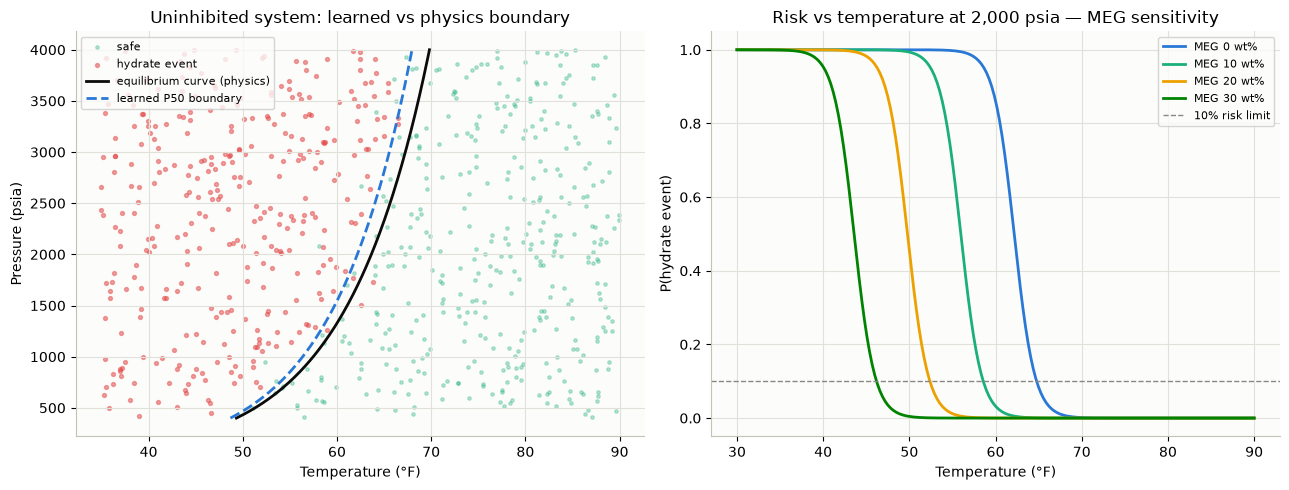

In [4]:
pp = np.linspace(400, 4_000, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = df.sample(1500, random_state=1)
no_meg = sample[sample.meg_wt_pct == 0]
axes[0].scatter(no_meg[no_meg.hydrate_event == 0].t_f, no_meg[no_meg.hydrate_event == 0].p_psia,
                s=6, alpha=0.3, color=PALETTE[1], label="safe")
axes[0].scatter(no_meg[no_meg.hydrate_event == 1].t_f, no_meg[no_meg.hydrate_event == 1].p_psia,
                s=8, alpha=0.5, color=PALETTE[5], label="hydrate event")
axes[0].plot(t_eq(pp, 0), pp, lw=2, color="#0b0b0b", label="equilibrium curve (physics)")
# learned 50% boundary at MEG=0
t_learned = -(w[0] * np.log(pp) + b) / w[1]
axes[0].plot(t_learned, pp, lw=2, ls="--", color=PALETTE[0], label="learned P50 boundary")
axes[0].set(xlabel="Temperature (°F)", ylabel="Pressure (psia)",
            title="Uninhibited system: learned vs physics boundary")
axes[0].legend(fontsize=8)

# probability contours vs MEG at fixed P
for i, meg in enumerate([0, 10, 20, 30]):
    grid = pd.DataFrame({"ln_p": np.log(2_000), "t_f": np.linspace(30, 90, 200),
                         "meg_wt_pct": meg})
    proba = clf.predict_proba(grid[FEATURES])[:, 1]
    axes[1].plot(grid.t_f, proba, lw=2, color=PALETTE[i], label=f"MEG {meg} wt%")
axes[1].axhline(0.1, ls="--", lw=1, color="#898781", label="10% risk limit")
axes[1].set(xlabel="Temperature (°F)", ylabel="P(hydrate event)",
            title="Risk vs temperature at 2,000 psia — MEG sensitivity")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Minimum safe temperature table (operations handout)

In [5]:
rows = []
for p in [1_000, 2_000, 3_000, 4_000]:
    for meg in [0, 10, 20, 30]:
        grid = pd.DataFrame({"ln_p": np.log(p), "t_f": np.linspace(20, 95, 400),
                             "meg_wt_pct": meg})
        proba = clf.predict_proba(grid[FEATURES])[:, 1]
        safe_idx = np.argmax(proba < 0.10)
        rows.append({"p_psia": p, "meg_wt_pct": meg,
                     "min_safe_T_F": round(grid.t_f.iloc[safe_idx], 1)})
print(pd.DataFrame(rows).pivot(index="p_psia", columns="meg_wt_pct",
                               values="min_safe_T_F"))

meg_wt_pct    0     10    20    30
p_psia                            
1000        59.1  52.9  46.7  40.5
2000        64.9  58.7  52.5  46.3
3000        68.3  62.1  55.9  49.7
4000        70.8  64.5  58.3  52.1


## Conclusions

* The logistic model **rediscovers the Katz-shaped boundary** (T ∝ ln P) and the MEG
  depression coefficient from operating data alone — the physics-comparable feature
  design makes that verification possible, unlike a black-box classifier.
* The learned boundary sits slightly inside the equilibrium curve, correctly reflecting
  kinetics: excursions need ~1.5°F of subcooling before plugs actually form.
* The min-safe-temperature table is the deliverable a control room can use directly.
* **Next step:** add water cut and salinity, and time-at-subcooling (kinetic) features
  for shut-in/restart transient risk.